In [10]:
from dataloaders import SequentialCIFAR10
from torch.optim import AdamW
from tqdm.auto import tqdm
from torch import optim
from torch import nn
import torch
import torch.nn.functional as F
from losses import SupConLoss
import matplotlib.pyplot as plt

In [ ]:
seq_cifar = SequentialCIFAR10(data_root="./data", batch_size=32, buffer_size=200)
train_loader, val_loader = seq_cifar.get_train_val_loaders(task_id=0, use_buffer=False)

In [3]:
class CNN(nn.Module):
   def __init__(self, in_channels, embedding_dim):

       super(CNN, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 8 * 8, embedding_dim)

   def forward(self, x):
       x = F.relu(self.conv1(x))
       x = self.pool(x)
       x = F.relu(self.conv2(x))
       x = self.pool(x)
       x = x.reshape(x.shape[0], -1)
       x = self.fc1(x)
       return x

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CNN(in_channels=3, embedding_dim=32).to(device)
criterion = SupConLoss(tau=0.07)
optimizer = AdamW(model.parameters(), lr=5e-5)
model2 = CNN(in_channels=3, embedding_dim=32).to(device)


In [5]:
def train(model, train_dataloader, val_dataloader, optimizer, criterion, lr_scheduler=None, num_epochs=10, device="cpu"):
    train_losses = []
    val_losses = []

    for epoch in tqdm(range(num_epochs), desc="Training"):
        model.train()
        running_loss = 0.0

        for images, labels in train_dataloader: 
            images = images.to(device)
            labels = labels.to(device)

            embeddings = model(images)
            loss = criterion(embeddings, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            if lr_scheduler is not None:
                lr_scheduler.step()

            running_loss += loss.item()
        train_losses.append(running_loss / len(train_dataloader))

        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_dataloader:
                images = images.to(device)
                labels = labels.to(device)
                embeddings = model(images)
                loss = criterion(embeddings, labels)
                running_val_loss += loss.item()

        val_losses.append(running_val_loss / len(val_dataloader))

    return train_losses, val_losses

In [6]:
train_losses, val_losses = train(model, train_loader, val_loader, optimizer, criterion, lr_scheduler=None, num_epochs=10, device=device)

Training:   0%|          | 0/10 [00:00<?, ?it/s]/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Training: 100%|██████████| 10/10 [06:47<00:00, 40.79s/it]


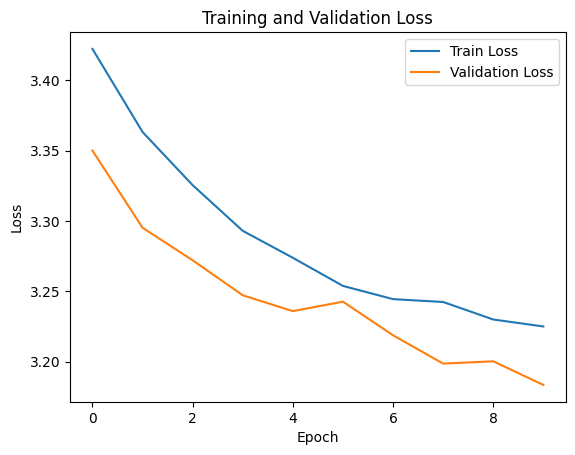

In [11]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [14]:
import os

os.makedirs("checkpoints", exist_ok=True)
checkpoint_path = "checkpoints/supcon_backbone_task0.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
}, checkpoint_path)

print(f"Backbone weights saved to: {checkpoint_path}")

Backbone weights saved to: checkpoints/supcon_backbone_task0.pt


In [15]:
class LinearProbe(nn.Module):
    def __init__(self, backbone, embedding_dim, num_classes):
        super().__init__()
        self.backbone = backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.backbone(x)
        return self.classifier(features)

num_classes_task0 = len(seq_cifar.task_classes[0])
linear_probe = LinearProbe(model, embedding_dim=32, num_classes=num_classes_task0).to(device)
linear_probe_criterion = nn.CrossEntropyLoss()
linear_probe_optimizer = AdamW(linear_probe.classifier.parameters(), lr=1e-3)

print("Linear probe ready: backbone frozen, classifier trainable.")

Linear probe ready: backbone frozen, classifier trainable.


In [16]:
def train_linear_probe_task0(
    linear_probe,
    train_dataloader,
    val_dataloader,
    optimizer,
    criterion,
    device,
    num_epochs=10,
    class_offset=0,
):
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    best_val_acc = -1.0
    best_classifier_state = None

    for epoch in range(num_epochs):
        linear_probe.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_dataloader:
            images = images.to(device)
            labels = labels.to(device) - class_offset

            logits = linear_probe(images)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / len(train_dataloader)
        train_acc = correct / total

        linear_probe.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_dataloader:
                images = images.to(device)
                labels = labels.to(device) - class_offset

                logits = linear_probe(images)
                val_loss = criterion(logits, labels)

                val_running_loss += val_loss.item()
                preds = logits.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / len(val_dataloader)
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_classifier_state = {
                key: value.detach().cpu().clone()
                for key, value in linear_probe.classifier.state_dict().items()
            }

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

    if best_classifier_state is not None:
        linear_probe.classifier.load_state_dict(best_classifier_state)

    print(f"Best validation accuracy (task 0): {best_val_acc:.4f}")
    return history

task0_classes = seq_cifar.task_classes[0]
task0_offset = min(task0_classes)

linear_probe_history = train_linear_probe_task0(
    linear_probe=linear_probe,
    train_dataloader=train_loader,
    val_dataloader=val_loader,
    optimizer=linear_probe_optimizer,
    criterion=linear_probe_criterion,
    device=device,
    num_epochs=10,
    class_offset=task0_offset,
)

/Users/alexanderbodner/Documents/Udesa/5to/vision avanzada/tp1_continual_learning/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 01/10 | train_loss=0.5753 train_acc=0.7888 | val_loss=0.4821 val_acc=0.8660
Epoch 02/10 | train_loss=0.4254 train_acc=0.8761 | val_loss=0.3872 val_acc=0.8770
Epoch 03/10 | train_loss=0.3622 train_acc=0.8809 | val_loss=0.3558 val_acc=0.8680
Epoch 04/10 | train_loss=0.3314 train_acc=0.8784 | val_loss=0.3440 val_acc=0.8650
Epoch 05/10 | train_loss=0.3157 train_acc=0.8758 | val_loss=0.3227 val_acc=0.8670
Epoch 06/10 | train_loss=0.3072 train_acc=0.8757 | val_loss=0.3195 val_acc=0.8670
Epoch 07/10 | train_loss=0.2958 train_acc=0.8778 | val_loss=0.3184 val_acc=0.8620
Epoch 08/10 | train_loss=0.2953 train_acc=0.8820 | val_loss=0.3249 val_acc=0.8620
Epoch 09/10 | train_loss=0.2952 train_acc=0.8808 | val_loss=0.2915 val_acc=0.8780
Epoch 10/10 | train_loss=0.2860 train_acc=0.8822 | val_loss=0.3120 val_acc=0.8740
Best validation accuracy (task 0): 0.8780


Best epoch: 9
Train accuracy at best epoch: 0.8808
Validation accuracy at best epoch: 0.8780


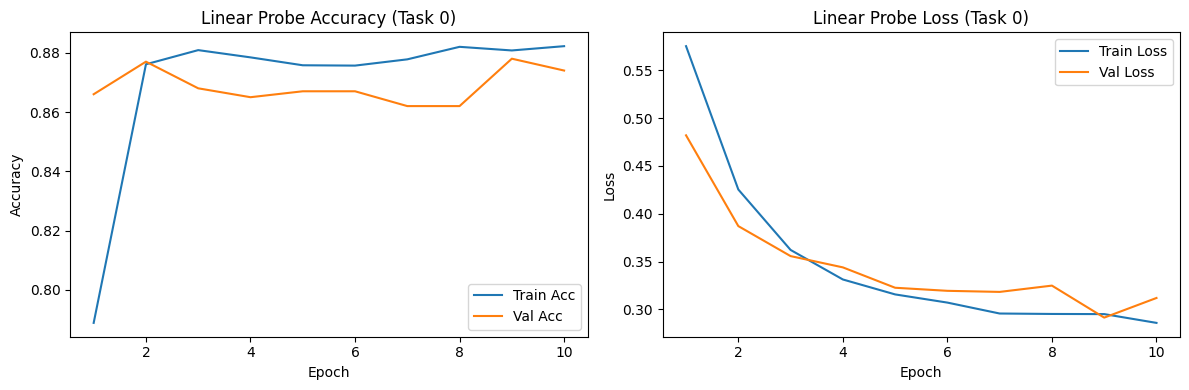

In [18]:
epochs = range(1, len(linear_probe_history["train_acc"]) + 1)
best_epoch = int(max(range(len(linear_probe_history["val_acc"])), key=lambda i: linear_probe_history["val_acc"][i])) + 1
best_val_acc = linear_probe_history["val_acc"][best_epoch - 1]
best_train_acc = linear_probe_history["train_acc"][best_epoch - 1]

print(f"Best epoch: {best_epoch}")
print(f"Train accuracy at best epoch: {best_train_acc:.4f}")
print(f"Validation accuracy at best epoch: {best_val_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, linear_probe_history["train_acc"], label="Train Acc")
axes[0].plot(epochs, linear_probe_history["val_acc"], label="Val Acc")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Linear Probe Accuracy (Task 0)")
axes[0].legend()

axes[1].plot(epochs, linear_probe_history["train_loss"], label="Train Loss")
axes[1].plot(epochs, linear_probe_history["val_loss"], label="Val Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Linear Probe Loss (Task 0)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
task0_test_loader = seq_cifar.get_task_il_test_loaders(up_to_task=0)[0]

linear_probe.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in task0_test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = linear_probe(images)
        preds = logits.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)

task0_test_acc = test_correct / test_total
print(f"Task 0 test accuracy (linear probe): {task0_test_acc:.4f}")